# MESSAGEix-Pakistan 
### Baseline Model
In this notebook, we are reading data and building baseline scenerio.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [1]:
# fundamental libraries
import os
import pandas as pd
import numpy as np
import ixmp
import message_ix
from message_ix import log


# for reporting and visualization
from modelFiles.plotter import plotter_MSG

# script functions
from modelFiles.utils import *
from modelFiles.adjust_capacity import adjust_capacity
from modelFiles.national_ev_policy import ev_shares
from modelFiles.adjust_transport import adjust_transport
from modelFiles.elec_gen_shares import generation_shares
from modelFiles.add_fuel_prices import add_fuel_prices
from modelFiles.update_calibration import model_calibrate
# from modelFiles.adjust_activity import adjust_activity


# autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
%reload_ext autoreload
%matplotlib inline

In [2]:
# saving current working directory path for later repeated use
cwd_path = os.getcwd()

Create scenario

In [3]:
# creating ixmp platform object
new_mp = ixmp.Platform("committed 6.0")

# creating a new, empty scenario object
scenario = message_ix.Scenario(
    new_mp, model="COMMITTED", scenario="baseline", version="new"
)

Read Data

In [4]:
# loading data (sets & parameters) into our model - latest data file is MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx
data_path = "./modelData/MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx"
scenario.read_excel(data_path, add_units=True, commit_steps=False, init_items=True,)

In [5]:
scenario = scenario.clone(scenario.model, "baseline", keep_solution=False, shift_first_model_year=2025)

In [6]:
# keep the model's temporal scope till 2070 only
modify_last_year(scenario, 2070)

In [7]:
tecs = ["loil_imp", "oil_imp", "coal_imp"]
insert_history(scenario, 2020, tecs)


In [8]:
# capacity
adjust_capacity(scenario)

In [9]:
# adjust_activity(scenario)

In [10]:
calibrate_solar(scenario)

In [11]:
calibrate_coal(scenario)

In [12]:
adjust_transport(scenario)

In [12]:
# # list of technologies outputing on the demand level
# tec_list = list(set((scenario.par(
#                 'output', {'level': 'useful',
#                         'commodity': 'i_therm'}))['technology']))

In [13]:
# print(tec_list)

In [14]:
# scenario.check_out()

In [15]:
# scenario.remove_solution()

In [13]:
ev_shares(scenario)

In [ ]:
# generation_shares(scenario)

In [14]:
scenario.remove_set("technology", "igcc")

In [19]:
# scenario.remove_set("node", "R12_GLB")

In [15]:
scenario.set("cat_tec", {"type_tec":["powerplant_low-carbon", "powerplant_fossil", "powerplant_hydro"]})

,type_tec,technology
0,powerplant_fossil,c_ppl_co2scr
1,powerplant_fossil,cement_co2scr
2,powerplant_fossil,coal_adv
3,powerplant_fossil,coal_adv_ccs
4,powerplant_fossil,coal_hpl
...,...,...
79,powerplant_low-carbon,wind_ref5
80,powerplant_low-carbon,wind_res1
81,powerplant_low-carbon,wind_res2
82,powerplant_low-carbon,wind_res3


In [21]:
# model_calibrate(scenario, nodeNames=["R12_PAK"], replace_negative=False)

##### Solve the Model

In [16]:
log.info(f"version number before commit(): {scenario.version}")

# commit the model structure and input data (sets and parameters)
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

# exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# solve model
scenario.solve(case=caseName)

scenario.var("OBJ")["lvl"]

ModelError: GAMS errored with return code 3:
    There was an execution error

For details, see the terminal output above, plus:
Listing   : d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\MESSAGE_run.lst
Log file  : d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\MESSAGE_run.log
Input data: d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\data\MsgData_COMMITTED__baseline__v36.gdx

##### Reporting Results

In [15]:
from modelFiles.report.iamc_report_hackathon import report
from datetime import datetime
import time
timestamp = f"{str(datetime.now().strftime('%Y-%m-%d--%H-%M'))}"
start = time.time()
df, path_name= report(mp=new_mp, scen=scenario, out_dir="./output/reporting_outputs", out_file_timestamp = timestamp, IDEA_format=False)
end = time.time()

processing Table: Resource|Extraction
processing Table: Resource|Cumulative Extraction
processing Table: Primary Energy
PostProcess.out() got an unexpected keyword argument 'inpfilter'
processing Table: Primary Energy (substitution method)
PostProcess.out() got an unexpected keyword argument 'inpfilter'
processing Table: Final Energy
processing Table: Secondary Energy|Electricity
processing Table: Secondary Energy|Heat
processing Table: Secondary Energy
processing Table: Secondary Energy|Gases
processing Table: Secondary Energy|Solids
processing Table: Emissions|CO2
processing Table: Carbon Sequestration
processing Table: Emissions|BC
processing Table: Emissions|OC
processing Table: Emissions|CO
processing Table: Emissions|N2O
processing Table: Emissions|CH4
processing Table: Emissions|NH3
processing Table: Emissions|Sulfur
processing Table: Emissions|NOx
processing Table: Emissions|VOC
processing Table: Emissions|HFC
HFC125
No objects to concatenate
processing Table: Emissions
process

In [ ]:
# print(path_name)

##### Plotting Results

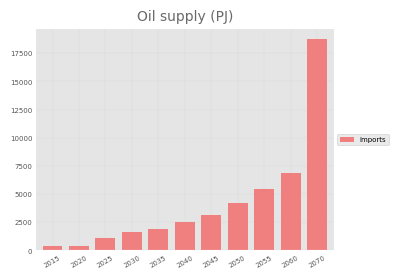

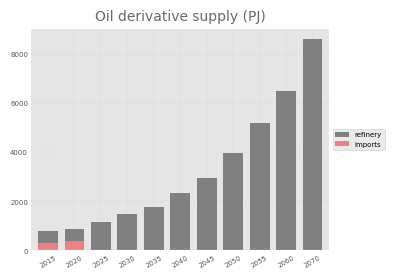

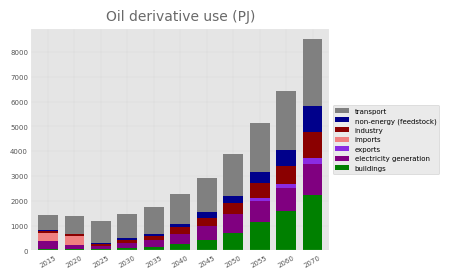

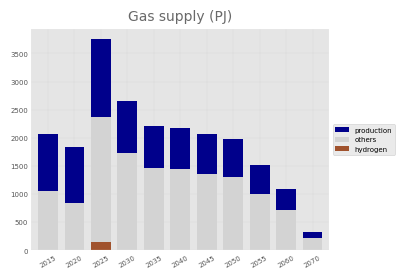

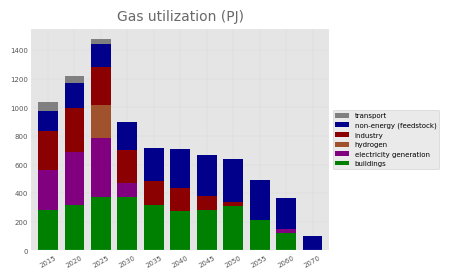

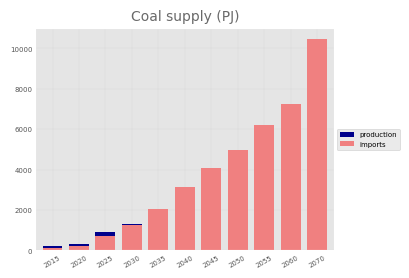

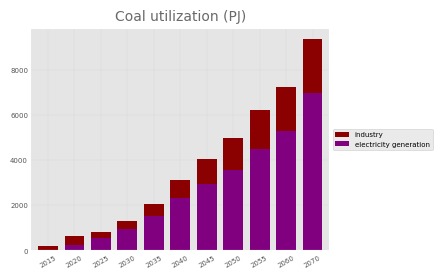

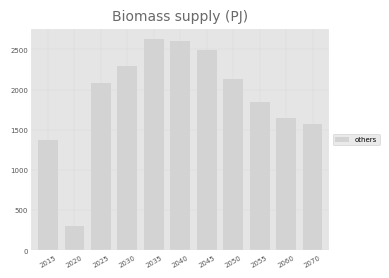

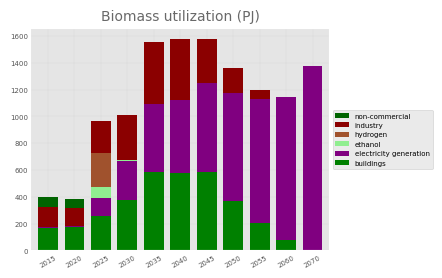

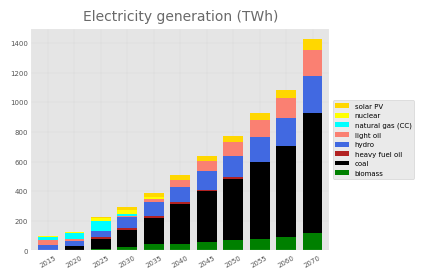

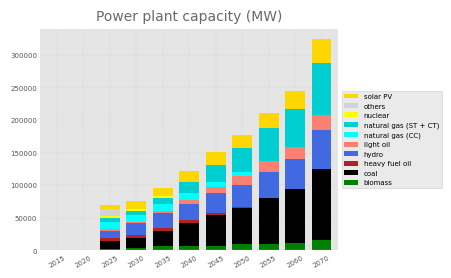

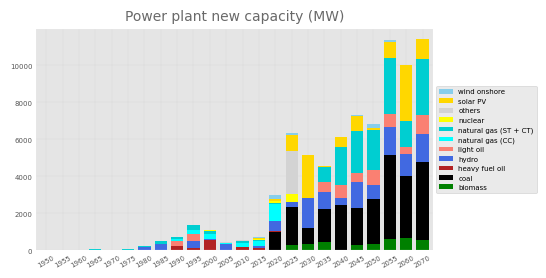

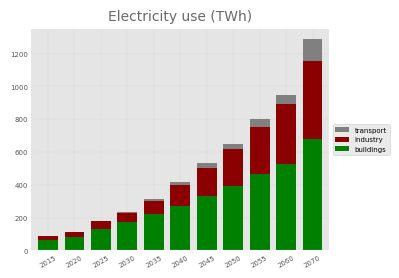

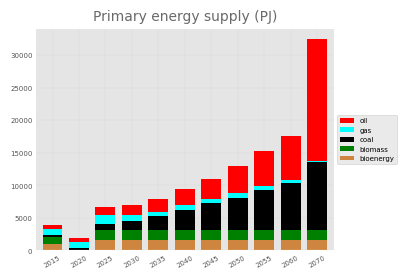

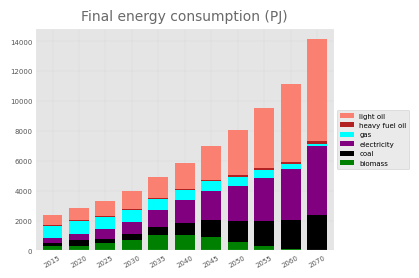

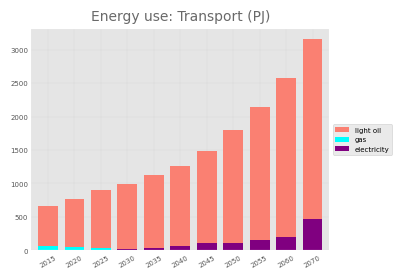

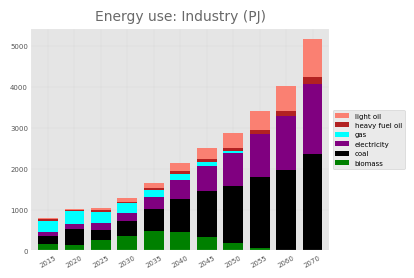

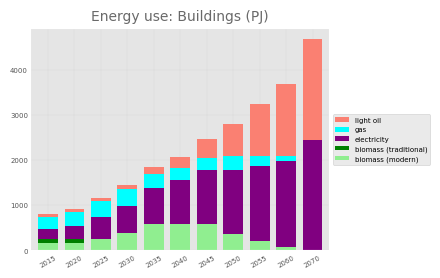

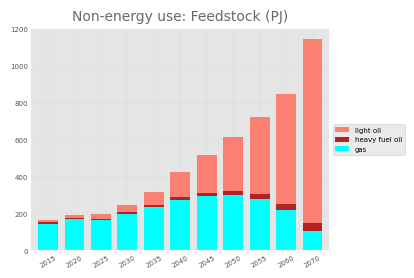

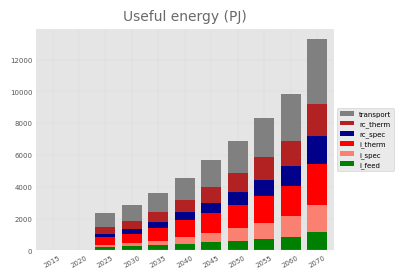

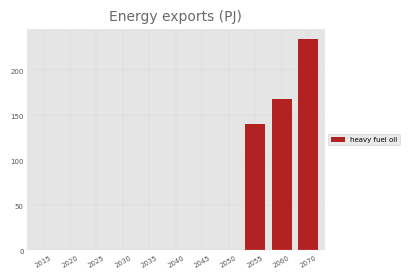

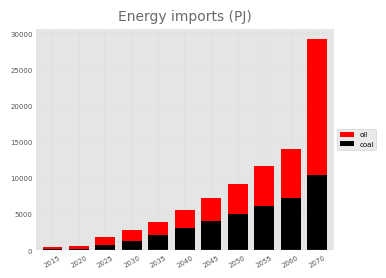

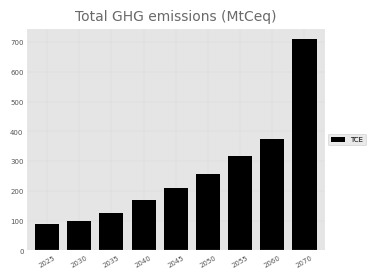

{'Electricity generation (TWh)':          biomass        coal  heavy fuel oil       hydro   light oil  \
 2015    0.556260    0.148044        0.000000   34.632660   35.362368   
 2020    0.711312   27.549324        0.000000   33.548172   17.195880   
 2025   11.409174   66.673793       15.401796   40.395918    0.000000   
 2030   24.049678  110.270852       16.305280   73.101488    9.798936   
 2035   42.345862  177.477107       12.871272   92.670669   20.767164   
 2040   45.363830  268.813312       11.565024  104.104097   46.938961   
 2045   55.426066  342.385191       11.200972  126.897951   64.284077   
 2050   67.462172  417.126863       10.142762  142.428411   93.117835   
 2055   77.444464  521.057172        0.000000  165.282561  119.829857   
 2060   88.952643  614.952850        0.000000  189.519762  134.313491   
 2070  114.650131  814.678792        0.000000  245.973520  178.330802   
 
       natural gas (CC)    nuclear   solar PV  
 2015         22.428041   4.605132   0.368

In [16]:
path = os.path.join(cwd_path, "output/plots")
plotter = plotter_MSG(scenario)
plotter.plotter(caseName, nodeloc=["R12_PAK"], path=path, yr_min=2015, yr_max=2070)

In [ ]:
# close the connection to the database
new_mp.close_db() 

In [ ]:
new_mp.open_db()